# Swin-Small comparison

# 0. Import all core dependencies

In [1]:
# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision import models

import timm
from timm.models.swin_transformer import SwinTransformerBlock

# Optimisers and Schedulers
from torch.optim import AdamW, RMSprop, SGD
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, StepLR

# Data Handling
from PIL import Image
import numpy as np
import pandas as pd
import cv2

# Data Visualisation - TODO
import matplotlib.pyplot as plt
import seaborn as sns

# Class Imbalance Handling - TODO
from imblearn.over_sampling import SMOTE
from collections import Counter

# Evaluation - TODO
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    recall_score
)

# Utilities
from tqdm import tqdm
from einops import rearrange
import os
import sys
import warnings
warnings.filterwarnings('ignore')

# Locate source helper files
NOTEBOOK_DIR = os.getcwd()

SRC_PATH = os.path.abspath("../../src")

if SRC_PATH not in sys.path:
    sys.path.append(SRC_PATH)

from datasets import FERDataset
from torchvision.transforms import v2

# Reproducibility
import random
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Configure PyTorch to use my GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device}")

C:\Users\aria_\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using cuda


# 2. Image Preprocessing function

In [2]:
transform_train = v2.Compose([
    v2.RandomAffine(degrees=10, scale=(0.8, 1.0), translate=(0.1, 0.1), interpolation=v2.InterpolationMode.BILINEAR, fill=0),
    v2.Resize(size=(224, 224), antialias=True), 
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

transform_test = v2.Compose([
    v2.Resize(size=(232, 232), interpolation=v2.InterpolationMode.BILINEAR, antialias=True),
    v2.CenterCrop(size=(224, 224)),
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

full_raf_train = FERDataset(os.path.abspath("../../datasets/RAFDB/DATASET/train"), transform_train)
raf_test = FERDataset(os.path.abspath("../../datasets/RAFDB/DATASET/test"), transform_test)
fer_test = FERDataset(os.path.abspath("../../datasets/FER2013/test"), transform_test)

train_size = int(0.8 * len(full_raf_train))
val_size = len(full_raf_train) - train_size

raf_train, raf_val = random_split(full_raf_train, [train_size, val_size])

train_loader = DataLoader(raf_train, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(raf_val, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_raf_loader = DataLoader(raf_test, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_fer_loader = DataLoader(fer_test, batch_size=32,shuffle=False, num_workers=4, pin_memory=True)

print(f"RAF-DB Training set images: {len(raf_train)}")
print(f"RAF-DB Validation set images: {len(raf_val)}")
print(f"RAF-DB Test set images: {len(raf_test)}")
print(f"FER2013 Test set images: {len(fer_test)}")

RAF-DB Training set images: 9816
RAF-DB Validation set images: 2455
RAF-DB Test set images: 3068
FER2013 Test set images: 7178


# 3. Stage 1: End-to-End Training

## 3.1 Train Functions

### 3.1.1 Baseline Train Function

In [3]:
def train_one_epoch(model, data_loader, criterion, optimiser, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in tqdm(data_loader):
        images = images.to(device)
        labels = labels.to(device)

        optimiser.zero_grad()
        
        outputs = model(images)

        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()
        optimiser.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / len(data_loader)
    epoch_acc = correct * 100. / total
    return epoch_loss, epoch_acc

## 3.2 Validation Function

In [4]:
def validate(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in tqdm(data_loader):
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(data_loader)
    val_acc = correct * 100. / total
    
    return val_loss, val_acc

## 3.3 Training and Validation from source domain

### 3.3.1 Set up my model

In [9]:
PATH = "model_checkpoints/latest.pth"
os.makedirs("model_checkpoints", exist_ok=True)

epochs = 75

model = timm.create_model('swin_small_patch4_window7_224', num_classes=7, pretrained=True).to(device)
criterion = nn.CrossEntropyLoss()
optimiser = AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimiser, T_max=epochs, eta_min=1e-6)

start_epoch = 0

if os.path.exists(PATH):
    checkpoint = torch.load(PATH, map_location=device)
    start_epoch = checkpoint["epoch"] + 1
    print(f"Checkpoint found! Starting from epoch {start_epoch}...")
    
    model.load_state_dict(checkpoint["model_state_dict"])
    optimiser.load_state_dict(checkpoint["optimiser_state_dict"])
    scheduler.load_state_dict(checkpoint["scheduler_state_dict"])
else:
    print("No model checkpoints found. Starting from epoch 1...")

No model checkpoints found. Starting from epoch 1...


In [10]:
if start_epoch == 0:
    # Freeze backbone, train only head (Epochs 1-3)
    # This aligns the random head with the pre-trained body without wrecking the body
    for param in model.parameters():
        param.requires_grad = False
    for param in model.head.parameters(): # ResNet's head is called 'fc'
        param.requires_grad = True
        
    print("Warming up head (3 Epochs)...")
    # Use Adam for quick head alignment
    warmup_optim = AdamW(model.head.parameters(), lr=3e-3)
    
    for epoch in range(3):
        model.train()
        for images, labels in tqdm(train_loader, desc=f"Warmup {epoch+1}"):
            images, labels = images.to(device), labels.to(device)
            warmup_optim.zero_grad()
            loss = criterion(model(images), labels)
            loss.backward()
            warmup_optim.step()

    # Unfreeze and Train All (Epochs 4-30)
    print("Fine-tuning entire model...")
    for param in model.parameters():
        param.requires_grad = True

for epoch in range(start_epoch, epochs):
    print("="*60)
    print(f"Epoch {epoch+1}/{epochs}")
    
    print("Training on RAF-DB...")
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimiser, device)

    print("Validating on RAF-DB...")
    val_loss, val_acc = validate(model, val_loader, criterion, device)
    
    scheduler.step()

    print(f"RAF-DB Training    | Loss: {train_loss:.4f} | Accuracy: {train_acc:.2f}%")
    print(f"RAF-DB Validation  | Loss: {val_loss:.4f} | Accuracy: {val_acc:.2f}%")

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimiser_state_dict": optimiser.state_dict(),
        "scheduler_state_dict": scheduler.state_dict()
    }

    torch.save(checkpoint, PATH)
    
print("="*60)
torch.save(model.state_dict(), 'swin_small_baseline.pth')

Warming up head (3 Epochs)...


Warmup 3: 100%|██████████████████████████████████████████████████████████████████████| 307/307 [00:51<00:00,  5.92it/s]


Fine-tuning entire model...
Epoch 1/75
Training on RAF-DB...


100%|████████████████████████████████████████████████████████████████████████████████| 307/307 [02:10<00:00,  2.36it/s]


Validating on RAF-DB...


...

RAF-DB Training    | Loss: 0.0003 | Accuracy: 100.00%
RAF-DB Validation  | Loss: 1.1651 | Accuracy: 84.36%
Epoch 75/75
Training on RAF-DB...


100%|████████████████████████████████████████████████████████████████████████████████| 307/307 [02:09<00:00,  2.36it/s]


Validating on RAF-DB...


100%|██████████████████████████████████████████████████████████████████████████████████| 77/77 [00:18<00:00,  4.26it/s]


RAF-DB Training    | Loss: 0.0004 | Accuracy: 99.98%
RAF-DB Validation  | Loss: 1.1740 | Accuracy: 84.07%


In [11]:
criterion = nn.CrossEntropyLoss()

print("Testing on RAF-DB...")
raf_loss, raf_acc = validate(model, test_raf_loader, criterion, device)

print("Testing of FER2013...")
fer_loss, fer_acc = validate(model, test_fer_loader, criterion, device)

print(f"RAF-DB Testing  | Loss: {raf_loss:.4f} | Accuracy: {raf_acc:.2f}%")
print(f"FER2013 Testing | Loss: {fer_loss:.4f} | Accuracy: {fer_acc:.2f}%")

Testing on RAF-DB...


100%|██████████████████████████████████████████████████████████████████████████████████| 96/96 [00:22<00:00,  4.33it/s]


Testing of FER2013...


100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:40<00:00,  5.61it/s]

RAF-DB Testing  | Loss: 1.0956 | Accuracy: 85.27%
FER2013 Testing | Loss: 5.2906 | Accuracy: 53.69%


Save an interrupted model:

In [6]:
torch.save(model.state_dict(), 'swin_xception_baseline.pth')

NameError: name 'model' is not defined

Load a baseline model:

In [5]:
model = timm.create_model('swin_small_patch4_window7_224', num_classes=7, pretrained=True).to(device)

swin_small_baseline = torch.load('swin_small_baseline.pth', map_location=device)

model.load_state_dict(swin_small_baseline)
print(f"Base Swin model loaded!")

Base Swin model loaded!


# 4. Evaluation and Metrics, Initial training

## 4.1 Confusion matrix

### 4.1.1 Run one evaluation to get all predictions

In [6]:
def get_predictions(model, dataloader, device):
    """Get all predictions and true labels"""
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Getting predictions"):
            images = images.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    return np.array(all_preds), np.array(all_labels)

### 4.1.2 Plotting the confusion matrices

In [7]:
def plot_confusion_matrix(y_true, y_pred, class_names, title, save_path=None):
    """Plot and optionally save confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    # Normalize to percentages
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # Raw counts
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names, ax=ax1)
    ax1.set_title(f'{title} - Raw Counts')
    ax1.set_ylabel('True Label')
    ax1.set_xlabel('Predicted Label')
    
    # Percentages
    sns.heatmap(cm_normalized, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax2)
    ax2.set_title(f'{title} - Percentages (%)')
    ax2.set_ylabel('True Label')
    ax2.set_xlabel('Predicted Label')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved confusion matrix to {save_path}")
    
    plt.show()

### 4.1.3 Detailed metrics

In [8]:
def print_detailed_metrics(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Per-class accuracy
    cm = confusion_matrix(y_true, y_pred)
    per_class_acc = cm.diagonal() / cm.sum(axis=1) * 100
    
    print("\nPer-Class Accuracy:")
    for i, (class_name, acc) in enumerate(zip(class_names, per_class_acc)):
        print(f"{class_name:12s}: {acc:6.2f}%")
    
    # Overall accuracy
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"\nOverall Accuracy: {overall_acc:.2f}%")

### 4.1.4 Generate Matrices


Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:25<00:00,  3.83it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


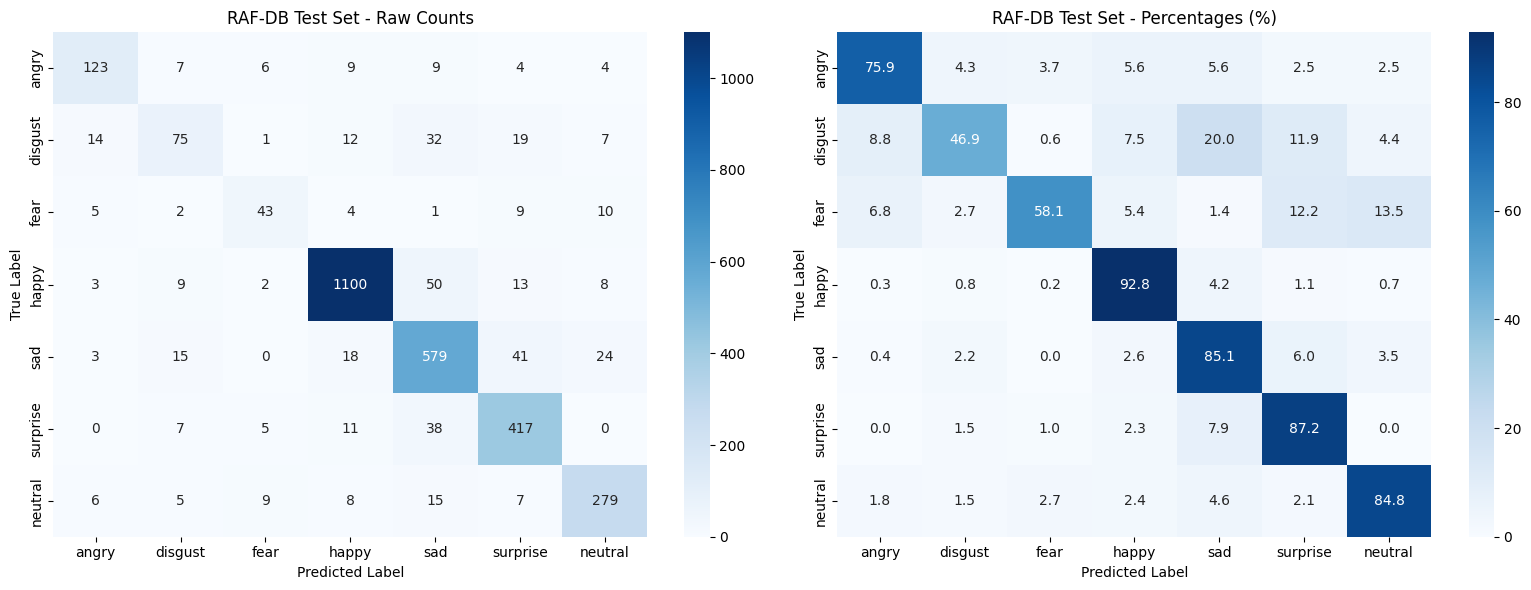


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.7987    0.7593    0.7785       162
     disgust     0.6250    0.4688    0.5357       160
        fear     0.6515    0.5811    0.6143        74
       happy     0.9466    0.9283    0.9374      1185
         sad     0.7997    0.8515    0.8248       680
    surprise     0.8176    0.8724    0.8441       478
     neutral     0.8404    0.8480    0.8442       329

    accuracy                         0.8527      3068
   macro avg     0.7828    0.7585    0.7684      3068
weighted avg     0.8509    0.8527    0.8508      3068


Per-Class Accuracy:
angry       :  75.93%
disgust     :  46.88%
fear        :  58.11%
happy       :  92.83%
sad         :  85.15%
surprise    :  87.24%
neutral     :  84.80%

Overall Accuracy: 85.27%

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:41<00:00,  5.36it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


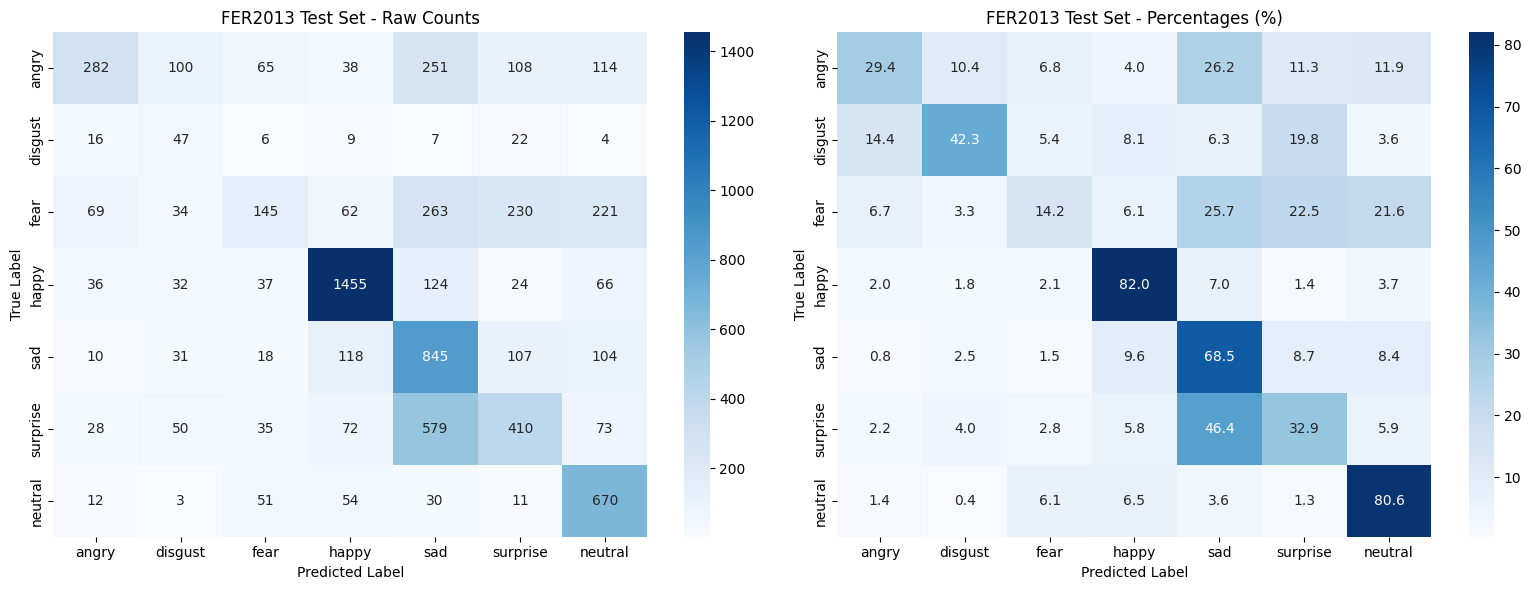


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6225    0.2944    0.3997       958
     disgust     0.1582    0.4234    0.2304       111
        fear     0.4062    0.1416    0.2100      1024
       happy     0.8048    0.8202    0.8124      1774
         sad     0.4026    0.6853    0.5072      1233
    surprise     0.4496    0.3288    0.3798      1247
     neutral     0.5351    0.8063    0.6433       831

    accuracy                         0.5369      7178
   macro avg     0.4827    0.5000    0.4547      7178
weighted avg     0.5516    0.5369    0.5152      7178


Per-Class Accuracy:
angry       :  29.44%
disgust     :  42.34%
fear        :  14.16%
happy       :  82.02%
sad         :  68.53%
surprise    :  32.88%
neutral     :  80.63%

Overall Accuracy: 53.69%


In [9]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics(fer_labels, fer_preds, emotions, 'FER2013')

### 4.1.5 Compare Minority class performance

In [27]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    fer_mask = fer_labels == cls_idx
    raf_mask = raf_labels == cls_idx
    
    if fer_mask.sum() > 0:
        fer_acc = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize()} - FER2013: {fer_acc:.2f}% ({fer_mask.sum()} samples)")
    
    if raf_mask.sum() > 0:
        raf_acc = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize()} - RAF-DB:  {raf_acc:.2f}% ({raf_mask.sum()} samples)")
    print()


Minority Class Performance (Disgust & Fear)
Disgust - FER2013: 33.33% (111 samples)
Disgust - RAF-DB:  39.38% (160 samples)

Fear - FER2013: 4.00% (1024 samples)
Fear - RAF-DB:  45.95% (74 samples)



## 4.2 UAR and WAR

### 4.2.1 UAR and WAR calculation

In [9]:
def calculate_uar_war(y_true, y_pred, class_names):
    """
    Calculate UAR and WAR metrics
    
    UAR (Unweighted Average Recall): Mean of per-class recalls (treats all classes equally)
    WAR (Weighted Average Recall): Weighted mean of per-class recalls (weighted by class frequency)
    """
    cm = confusion_matrix(y_true, y_pred)
    
    # Per-class recall (same as per-class accuracy for single-label classification)
    per_class_recall = cm.diagonal() / cm.sum(axis=1)
    
    # UAR: Simple average of all class recalls
    uar = np.mean(per_class_recall) * 100
    
    # WAR: Weighted average by class support
    class_support = cm.sum(axis=1)
    war = np.average(per_class_recall, weights=class_support) * 100
    
    return uar, war, per_class_recall

### 4.2.2 Detailed metrics with UAR and WAR

In [12]:
def print_detailed_metrics_with_uar_war(y_true, y_pred, class_names, dataset_name):
    """Print detailed classification metrics including UAR and WAR"""
    print(f"\n{'='*60}")
    print(f"{dataset_name} - Detailed Metrics")
    print(f"{'='*60}")
    
    # Standard classification report
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Calculate UAR and WAR
    uar, war, per_class_recall = calculate_uar_war(y_true, y_pred, class_names)
    
    print("\n" + "-"*60)
    print("Per-Class Recall (%):")
    print("-"*60)
    for class_name, recall in zip(class_names, per_class_recall):
        print(f"{class_name:12s}: {recall*100:6.2f}%")
    
    print("\n" + "-"*60)
    print("Summary Metrics:")
    print("-"*60)
    overall_acc = (y_true == y_pred).sum() / len(y_true) * 100
    print(f"Overall Accuracy: {overall_acc:.2f}%")
    print(f"WAR (Weighted Average Recall): {war:.2f}%")
    print(f"UAR (Unweighted Average Recall): {uar:.2f}%")
    print("-"*60)

### 4.2.3 Generate confusion matrices for test sets with UAR and WAR


Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:23<00:00,  4.14it/s]


Saved confusion matrix to rafdb_confusion_matrix.png


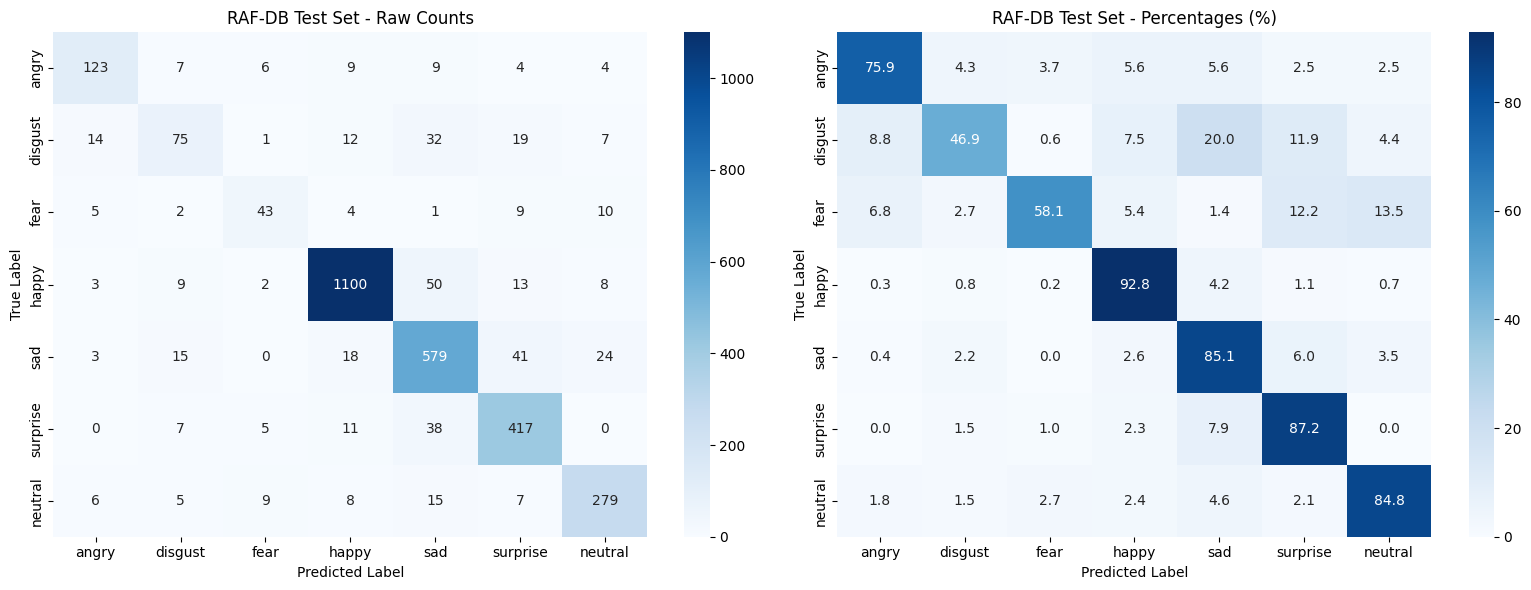


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.7987    0.7593    0.7785       162
     disgust     0.6250    0.4688    0.5357       160
        fear     0.6515    0.5811    0.6143        74
       happy     0.9466    0.9283    0.9374      1185
         sad     0.7997    0.8515    0.8248       680
    surprise     0.8176    0.8724    0.8441       478
     neutral     0.8404    0.8480    0.8442       329

    accuracy                         0.8527      3068
   macro avg     0.7828    0.7585    0.7684      3068
weighted avg     0.8509    0.8527    0.8508      3068


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  75.93%
disgust     :  46.88%
fear        :  58.11%
happy       :  92.83%
sad         :  85.15%
surprise    :  87.24%
neutral     :  84.80%

------------------------------------------------------------
Summary Metrics

Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:39<00:00,  5.65it/s]


Saved confusion matrix to fer2013_confusion_matrix.png


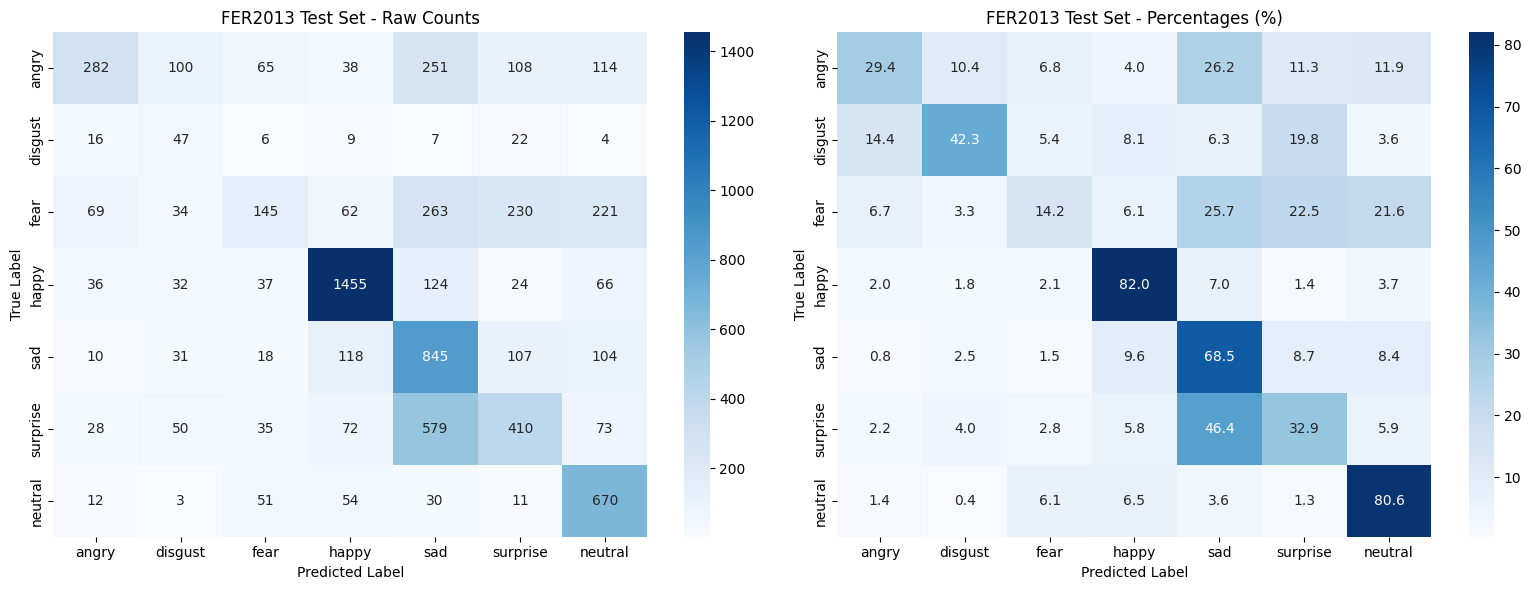


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6225    0.2944    0.3997       958
     disgust     0.1582    0.4234    0.2304       111
        fear     0.4062    0.1416    0.2100      1024
       happy     0.8048    0.8202    0.8124      1774
         sad     0.4026    0.6853    0.5072      1233
    surprise     0.4496    0.3288    0.3798      1247
     neutral     0.5351    0.8063    0.6433       831

    accuracy                         0.5369      7178
   macro avg     0.4827    0.5000    0.4547      7178
weighted avg     0.5516    0.5369    0.5152      7178


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  29.44%
disgust     :  42.34%
fear        :  14.16%
happy       :  82.02%
sad         :  68.53%
surprise    :  32.88%
neutral     :  80.63%

------------------------------------------------------------
Summary Metric

In [13]:
print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix.png')
print_detailed_metrics_with_uar_war(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix.png')
print_detailed_metrics_with_uar_war(fer_labels, fer_preds, emotions, 'FER2013')

### 4.2.4 Summary Comparison Table

In [14]:
print("\n" + "="*60)
print("Cross-Dataset Performance Summary")
print("="*60)

raf_uar, raf_war, _ = calculate_uar_war(raf_labels, raf_preds, emotions)
fer_uar, fer_war, _ = calculate_uar_war(fer_labels, fer_preds, emotions)

raf_acc = (raf_preds == raf_labels).sum() / len(raf_labels) * 100
fer_acc = (fer_preds == fer_labels).sum() / len(fer_labels) * 100

print(f"\n{'Metric':<30} {'FER2013':>12} {'RAF-DB':>12}")
print("-"*60)
print(f"{'Overall Accuracy':<30} {raf_acc:>11.2f}% {fer_acc:>11.2f}%")
print(f"{'WAR (Weighted Avg Recall)':<30} {raf_war:>11.2f}% {fer_war:>11.2f}%")
print(f"{'UAR (Unweighted Avg Recall)':<30} {raf_uar:>11.2f}% {fer_uar:>11.2f}%")
print("-"*60)


Cross-Dataset Performance Summary

Metric                              FER2013       RAF-DB
------------------------------------------------------------
Overall Accuracy                     85.27%       53.69%
WAR (Weighted Avg Recall)            85.27%       53.69%
UAR (Unweighted Avg Recall)          75.85%       50.00%
------------------------------------------------------------


### 4.2.5 Minority Class Performance with UAR and WAR

In [11]:
print("\n" + "="*60)
print("Minority Class Performance (Disgust & Fear)")
print("="*60)

minority_classes = ['disgust', 'fear']
minority_indices = [emotions.index(cls) for cls in minority_classes]

print(f"\n{'Class':<12} {'Dataset':<10} {'Recall':<10} {'Samples':<10}")
print("-"*60)

for cls_name, cls_idx in zip(minority_classes, minority_indices):
    
    # RAF-DB
    raf_mask = raf_labels == cls_idx
    if raf_mask.sum() > 0:
        raf_recall = (raf_preds[raf_mask] == raf_labels[raf_mask]).sum() / raf_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'RAF-DB':<10} {raf_recall:>8.2f}% {raf_mask.sum():>9}")

    # FER2013
    fer_mask = fer_labels == cls_idx
    if fer_mask.sum() > 0:
        fer_recall = (fer_preds[fer_mask] == fer_labels[fer_mask]).sum() / fer_mask.sum() * 100
        print(f"{cls_name.capitalize():<12} {'FER2013':<10} {fer_recall:>8.2f}% {fer_mask.sum():>9}")
    
    print()


Minority Class Performance (Disgust & Fear)

Class        Dataset    Recall     Samples   
------------------------------------------------------------


NameError: name 'raf_labels' is not defined

# 5. Stage 2: Feature Extraction and Synthesis

## 5.1 Extract Features

In [21]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting Features"):
            images = images.to(device)

            x = model.patch_embed(images)

            for block in model.layer1:
                x = block(x)
            x = model.merge1(x)

            for block in model.layer2:
                x = block(x)
            x = model.merge2(x)

            for block in model.layer3:
                x = block(x)
            x = model.merge3(x)
            
            for block in model.layer4:
                x = block(x)

            x = model.norm(x)
            x = x.transpose(1, 2)
            x = model.avgpool1d(x)
            x = torch.flatten(x, 1)

            all_features.append(x.cpu().numpy())
            all_labels.append(labels.numpy())

        features = np.vstack(all_features)
        labels = np.concatenate(all_labels)

        return features, labels

## 5.2 Apply SMOTE on extracted deep features

In [22]:
def apply_smote(features, labels, random_state=42):
    print("Original class distribution:")
    print(Counter(labels))
    
    smote = SMOTE(random_state=random_state, k_neighbors=5)
    balanced_features, balanced_labels = smote.fit_resample(features, labels)

    print("Balanced class distribution:")
    print(Counter(balanced_labels))

    return balanced_features, balanced_labels

In [23]:
features, labels = extract_features(model, train_loader, device)
balanced_features, balanced_labels = apply_smote(features, labels)

Extracting Features: 100%|███████████████████████████████████████████████████████████| 307/307 [00:47<00:00,  6.53it/s]


Original class distribution:
Counter({np.int64(3): 3865, np.int64(4): 2010, np.int64(5): 1579, np.int64(6): 1004, np.int64(1): 576, np.int64(0): 558, np.int64(2): 224})
Balanced class distribution:
Counter({np.int64(3): 3865, np.int64(5): 3865, np.int64(0): 3865, np.int64(4): 3865, np.int64(6): 3865, np.int64(2): 3865, np.int64(1): 3865})


# 6. Stage 3: Retraining the MLP Head

In [24]:
def retrain_mlp_head(model, features, labels, device, epochs=20, batch_size=128, lr=1e-3, weight_decay=1e-3):
    # Freeze all params in Swin-X backbone
    for param in model.patch_embed.parameters():
        param.requires_grad = False
    for stage in [model.layer1, model.layer2, model.layer3, model.layer4]:
        for block in stage:
            for param in block.parameters():
                param.requires_grad = False

    for merge in [model.merge1, model.merge2, model.merge3]:
        for param in merge.parameters():
            param.requires_grad = False

    for param in model.head.parameters():
        param.requires_grad = True

    features_tensor = torch.FloatTensor(features)
    labels_tensor = torch.LongTensor(labels)
    dataset = torch.utils.data.TensorDataset(features_tensor, labels_tensor)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    criterion = nn.CrossEntropyLoss()
    optimiser = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        correct = 0
        total = 0

        for batch_features, batch_labels in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}"):
            batch_features = batch_features.to(device)
            batch_labels = batch_labels.to(device)

            optimiser.zero_grad()

            outputs = model.head(batch_features)

            loss = criterion(outputs, batch_labels)

            loss.backward()
            optimiser.step()
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += batch_labels.size(0)
            correct += predicted.eq(batch_labels).sum().item()

        epoch_loss = running_loss / len(dataloader)
        epoch_acc = correct * 100. / total

        print(f"Epoch {epoch+1}/{epochs}   Loss: {epoch_loss}   Accuracy: {epoch_acc}")

    return model

In [25]:
model = retrain_mlp_head(model, balanced_features, balanced_labels, device)

torch.save(model.state_dict(), 'swin_xception_final.pth')

Epoch 1/20: 100%|███████████████████████████████████████████████████████████████████| 212/212 [00:01<00:00, 118.64it/s]


Epoch 1/20   Loss: 0.49847687387241507   Accuracy: 81.88135279985215


Epoch 2/20: 100%|███████████████████████████████████████████████████████████████████| 212/212 [00:01<00:00, 145.33it/s]


Epoch 2/20   Loss: 0.48927636388337836   Accuracy: 82.18074293106635


Epoch 3/20: 100%|███████████████████████████████████████████████████████████████████| 212/212 [00:01<00:00, 163.92it/s]


...

Epoch 18/20   Loss: 0.47930097973571634   Accuracy: 82.50600628349657


Epoch 19/20: 100%|██████████████████████████████████████████████████████████████████| 212/212 [00:01<00:00, 142.62it/s]


Epoch 19/20   Loss: 0.47981538989071576   Accuracy: 82.82757346146738


Epoch 20/20: 100%|██████████████████████████████████████████████████████████████████| 212/212 [00:01<00:00, 162.42it/s]


Epoch 20/20   Loss: 0.47961372685319975   Accuracy: 82.71668822768434


In [12]:
model = SwinXception(num_classes=7).to(device)

swin_xception_final = torch.load('swin_xception_final.pth', map_location=device)

model.load_state_dict(swin_xception_final)
print(f"Post-SMOTE SwinXception model loaded!")

Post-SMOTE SwinXception model loaded!


In [8]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 48842641


# 7. Evaluation Metrics and Visualisation on Balanced set

## 7.1 Validate Loss and Accuracy on Test sets

In [19]:
raf_loss, raf_acc = validate(model, test_raf_loader, nn.CrossEntropyLoss(), device)
fer_loss, fer_acc = validate(model, test_fer_loader, nn.CrossEntropyLoss(), device)

print(f"RAF-DB | new loss: {raf_loss:.4f} | new accuracy: {raf_acc:.2f}")
print(f"FER2013 | new loss: {fer_loss:.4f} | new accuracy: {fer_acc:.2f}")

100%|████████████████████████████████████████████████████████████████████████████████| 225/225 [00:36<00:00,  6.19it/s]

RAF-DB | new loss: 0.8708 | new accuracy: 73.60
FER2013 | new loss: 2.5148 | new accuracy: 40.47



Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:21<00:00,  4.47it/s]


Saved confusion matrix to rafdb_confusion_matrix_final.png


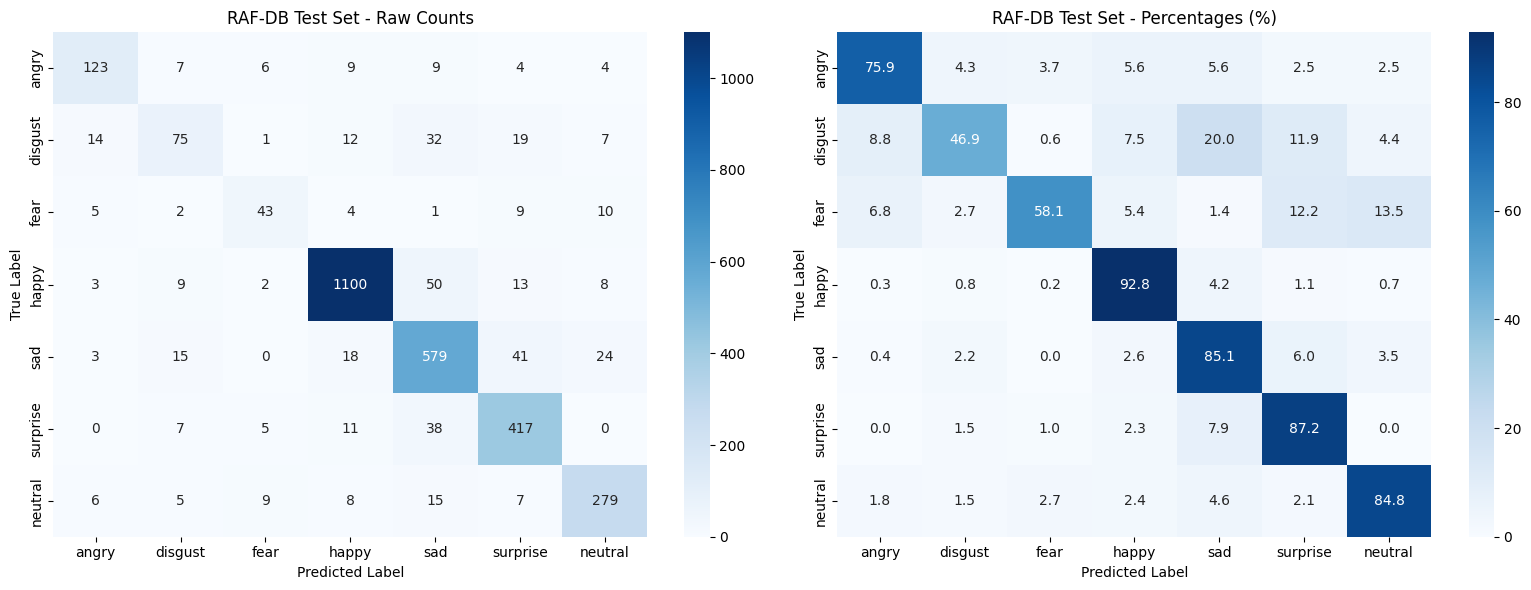


RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.7987    0.7593    0.7785       162
     disgust     0.6250    0.4688    0.5357       160
        fear     0.6515    0.5811    0.6143        74
       happy     0.9466    0.9283    0.9374      1185
         sad     0.7997    0.8515    0.8248       680
    surprise     0.8176    0.8724    0.8441       478
     neutral     0.8404    0.8480    0.8442       329

    accuracy                         0.8527      3068
   macro avg     0.7828    0.7585    0.7684      3068
weighted avg     0.8509    0.8527    0.8508      3068


Per-Class Accuracy:
angry       :  75.93%
disgust     :  46.88%
fear        :  58.11%
happy       :  92.83%
sad         :  85.15%
surprise    :  87.24%
neutral     :  84.80%

Overall Accuracy: 85.27%

Evaluating FER2013 test set...


Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:39<00:00,  5.72it/s]


Saved confusion matrix to fer2013_confusion_matrix_final.png


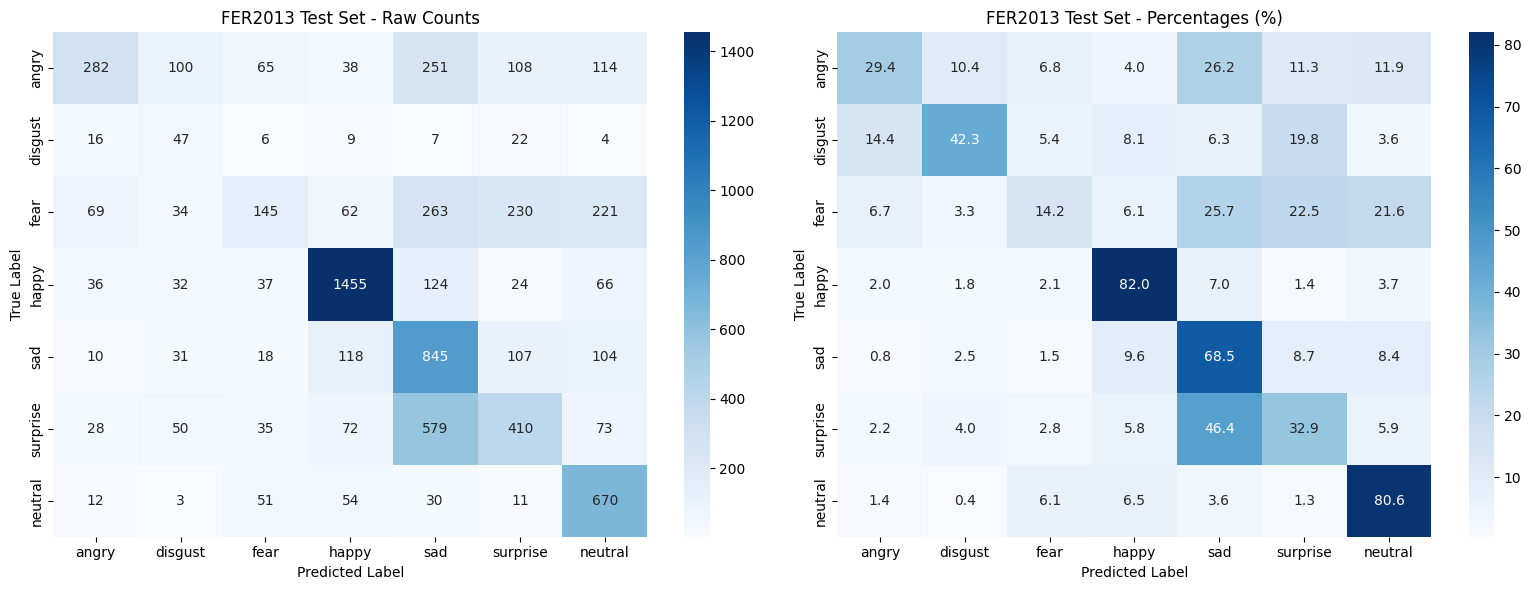


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6225    0.2944    0.3997       958
     disgust     0.1582    0.4234    0.2304       111
        fear     0.4062    0.1416    0.2100      1024
       happy     0.8048    0.8202    0.8124      1774
         sad     0.4026    0.6853    0.5072      1233
    surprise     0.4496    0.3288    0.3798      1247
     neutral     0.5351    0.8063    0.6433       831

    accuracy                         0.5369      7178
   macro avg     0.4827    0.5000    0.4547      7178
weighted avg     0.5516    0.5369    0.5152      7178


Per-Class Accuracy:
angry       :  29.44%
disgust     :  42.34%
fear        :  14.16%
happy       :  82.02%
sad         :  68.53%
surprise    :  32.88%
neutral     :  80.63%

Overall Accuracy: 53.69%


In [15]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
plot_confusion_matrix(raf_labels, raf_preds, emotions, 
                     'RAF-DB Test Set',
                     save_path='rafdb_confusion_matrix_final.png')
print_detailed_metrics(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
plot_confusion_matrix(fer_labels, fer_preds, emotions, 
                     'FER2013 Test Set', 
                     save_path='fer2013_confusion_matrix_final.png')
print_detailed_metrics(fer_labels, fer_preds, emotions, 'FER2013')

In [16]:
# Emotion labels
emotions = ['angry', 'disgust', 'fear', 'happy', 'sad', 'surprise', 'neutral']

print("\n" + "="*60)
print("Generating Confusion Matrices and Metrics")
print("="*60)

# RAF-DB Test Set
print("\nEvaluating RAF-DB test set...")
raf_preds, raf_labels = get_predictions(model, test_raf_loader, device)
print_detailed_metrics_with_uar_war(raf_labels, raf_preds, emotions, 'RAF-DB')

# FER2013 Test Set
print("\nEvaluating FER2013 test set...")
fer_preds, fer_labels = get_predictions(model, test_fer_loader, device)
print_detailed_metrics_with_uar_war(fer_labels, fer_preds, emotions, 'FER2013')


Generating Confusion Matrices and Metrics

Evaluating RAF-DB test set...


Getting predictions: 100%|█████████████████████████████████████████████████████████████| 96/96 [00:20<00:00,  4.68it/s]



RAF-DB - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.7987    0.7593    0.7785       162
     disgust     0.6250    0.4688    0.5357       160
        fear     0.6515    0.5811    0.6143        74
       happy     0.9466    0.9283    0.9374      1185
         sad     0.7997    0.8515    0.8248       680
    surprise     0.8176    0.8724    0.8441       478
     neutral     0.8404    0.8480    0.8442       329

    accuracy                         0.8527      3068
   macro avg     0.7828    0.7585    0.7684      3068
weighted avg     0.8509    0.8527    0.8508      3068


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  75.93%
disgust     :  46.88%
fear        :  58.11%
happy       :  92.83%
sad         :  85.15%
surprise    :  87.24%
neutral     :  84.80%

------------------------------------------------------------
Summary Metrics

Getting predictions: 100%|███████████████████████████████████████████████████████████| 225/225 [00:39<00:00,  5.68it/s]


FER2013 - Detailed Metrics
              precision    recall  f1-score   support

       angry     0.6225    0.2944    0.3997       958
     disgust     0.1582    0.4234    0.2304       111
        fear     0.4062    0.1416    0.2100      1024
       happy     0.8048    0.8202    0.8124      1774
         sad     0.4026    0.6853    0.5072      1233
    surprise     0.4496    0.3288    0.3798      1247
     neutral     0.5351    0.8063    0.6433       831

    accuracy                         0.5369      7178
   macro avg     0.4827    0.5000    0.4547      7178
weighted avg     0.5516    0.5369    0.5152      7178


------------------------------------------------------------
Per-Class Recall (%):
------------------------------------------------------------
angry       :  29.44%
disgust     :  42.34%
fear        :  14.16%
happy       :  82.02%
sad         :  68.53%
surprise    :  32.88%
neutral     :  80.63%

------------------------------------------------------------
Summary Metric